# Hotel Bookings (GP4)
Посмотрим на наш датасет, подготовим его к дальнейшему анализу: проведем Feature Engineering, Univariate analysis.

### Импортируем библиотеки и датасет

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('hotel_bookings.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### Проверим на дубликаты

In [120]:
df.duplicated().sum()

np.int64(31994)

Нашлось 31994 дубликатов. Очистим датасет от них

In [121]:
origin_shape0 = df.shape[0]
print(f'Количество строк до очистки от дубликатов: {origin_shape0}')
df = df.drop_duplicates()
print(f'Количество строк после удаления дубликатов: {df.shape[0]}. Дубликаты составляли {((origin_shape0 - df.shape[0]) / origin_shape0 * 100):.2f}% исходного датасета.')

Количество строк до очистки от дубликатов: 119390
Количество строк после удаления дубликатов: 87396. Дубликаты составляли 26.80% исходного датасета.


### Посмотрим каждый признак

#### Hotel

In [122]:
print(f'Пропусков у признака Hotel: {df['hotel'].isnull().sum()}')

Пропусков у признака Hotel: 0


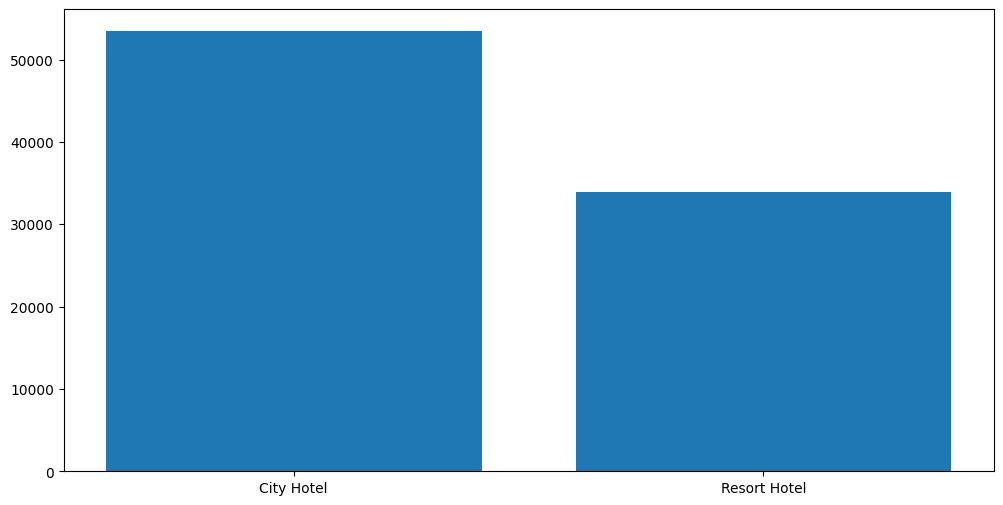

In [123]:

plt.figure(figsize=(12, 6))
plt.bar(df['hotel'].value_counts().index, df['hotel'].value_counts().values)
plt.show()

In [124]:
df['hotel'].value_counts() / df.shape[0] * 100

hotel
City Hotel      61.133233
Resort Hotel    38.866767
Name: count, dtype: float64

У нас всего два отеля: City Hotel - 61.13% и Resort Hotel - 38.87%. Пропусков нет. Можем предположить, что City Hotel более популярный в данном датасете - из-за меньшей привязки к сезонности, как, скорее всего, курортный отель - Resort Hotel. Но это будет рассмотрено уже в части анализа связи разных признаков.

#### is_canceled

In [125]:
print(f'Пропусков у признака is_canceled: {df['is_canceled'].isnull().sum()}')

Пропусков у признака is_canceled: 0


In [126]:
df['is_canceled'].value_counts() / df.shape[0] * 100

is_canceled
0    72.510184
1    27.489816
Name: count, dtype: float64

is_canceled - это основная целевая переменная - отменена ли бронь за отель. Мы видим дисбаланс классов, где не отменненых бронирований больше, но в реальности более высокое число успешных броней - нормально, почти 30% отмененных не так уж и мало.

#### lead_time

Это числовой признак, показывающий количество дней от даты внесения броня в базу, до дня прибытия

In [127]:
print(f'Пропусков у признака lead_time: {df['lead_time'].isnull().sum()}')

Пропусков у признака lead_time: 0


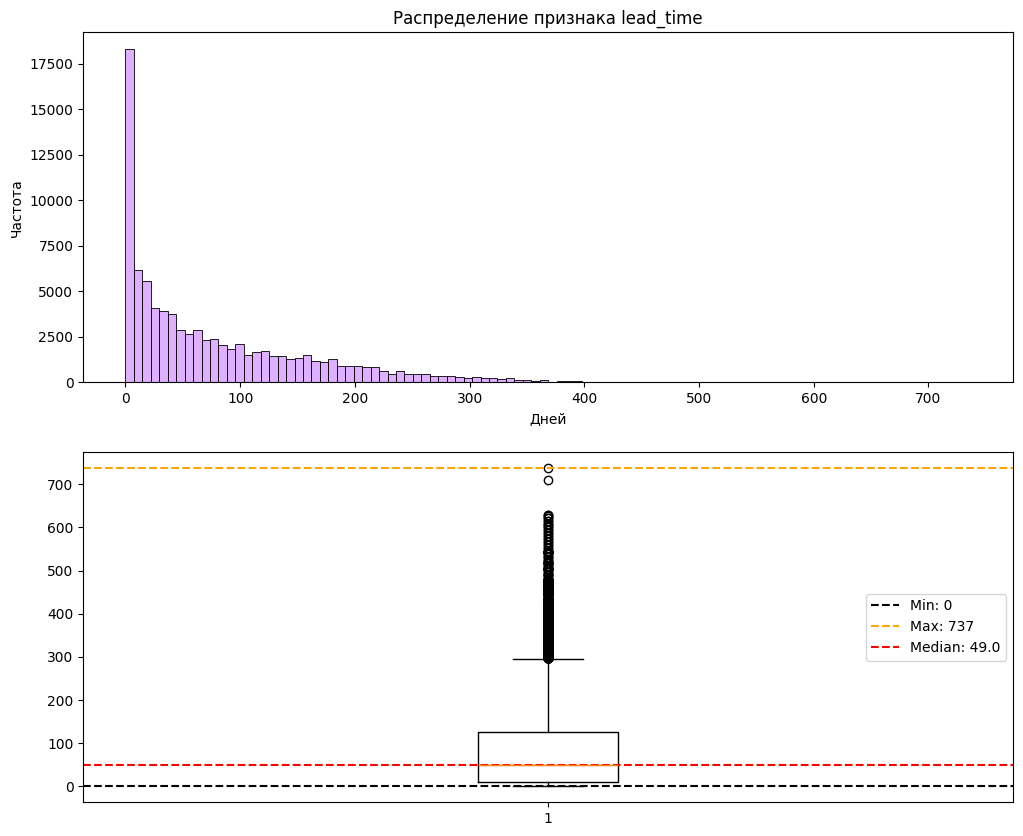

In [128]:
plt.figure(figsize=(12, 10))

plt.subplot(2,1,1)
plt.title('Распределение признака lead_time')
sns.histplot(df, x='lead_time', bins=100, color='#d596ff')
plt.xlabel('Дней')
plt.ylabel('Частота')

plt.subplot(2,1,2)
plt.boxplot(df['lead_time'])
plt.axhline(df['lead_time'].min(), color='black', linestyle='--', label=f'Min: {df['lead_time'].min()}')
plt.axhline(df['lead_time'].max(), color='orange', linestyle='--', label=f'Max: {df['lead_time'].max()}')
plt.axhline(df['lead_time'].median(), color='red', linestyle='--', label=f'Median: {df['lead_time'].median()}')
plt.legend()
plt.show()

У нас довольно много значений в районе 0, посмотрим чуть ближе на более короткий отрезок

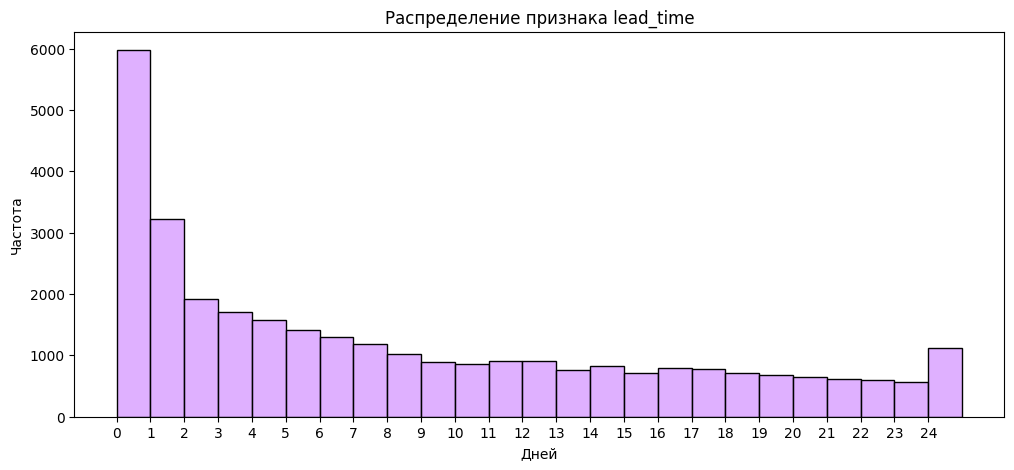

In [129]:
plt.figure(figsize=(12, 5))
plt.title('Распределение признака lead_time')
sns.histplot(df[df['lead_time'] <= 25], x='lead_time', bins=25, color='#d596ff')
plt.xlabel('Дней')
plt.ylabel('Частота')
plt.xticks(range(0, 25))

plt.show()

In [130]:
lead_time_25 = df[df['lead_time'] <= 25]['lead_time'].value_counts().reset_index()
lead_time_25['prc'] = lead_time_25['count'] / df.shape[0] * 100
lead_time_25

,lead_time,count,prc
0,0,5978,6.840130
1,1,3216,3.679802
2,2,1927,2.204906
3,3,1704,1.949746
4,4,1570,1.796421
5,5,1418,1.622500
6,6,1300,1.487482
7,7,1191,1.362763
8,8,1019,1.165957
9,12,915,1.046959


Большая часть - это бронирования сделанные, по всей видимости, в день заезда, то есть без брони заранее. Но при этом все равно чем меньше дней со дня брони до дня прибытия, то чем больше таких бронирований (по каждому дню отдельно). Посмотрим на две группы, разделив их неким порогом в 30 дней, то есть под "заранее забронировавших" возьмем тех, кто бронировал за месяц и более

In [131]:
under_30_lead_time = df[df['lead_time'] < 30]
more_30_lead_time = df[df['lead_time'] >= 30]

print(f'Доля бронирований в пределах месяца: {(under_30_lead_time.shape[0] / df.shape[0] * 100)}%')
print(f'Доля бронирований за месяц и более: {(more_30_lead_time.shape[0] / df.shape[0] * 100)}%')

Доля бронирований в пределах месяца: 39.028101972630324%
Доля бронирований за месяц и более: 60.971898027369676%


Хоть и рассматривая отдельное количество дней - 0, 1, 2 и т.д. дни популярнее, но, все равно, заранее бронируют чаще. Далее мы сможем выделить более подробные когорты, которые далее можно будет сравнивать по другим признакам.

#### Признаки, характеризирующие дату
Автор датасета выполнил вероятную часть нашей работы - детализировал дату на различные колонки (год, месяц, номер недели, день месяца). Посмотрим на них всех в одном блоке.

Проверим сразу все на дубликаты

In [132]:
print(f'Пропусков у признака arrival_date_year: {df['arrival_date_year'].isnull().sum()}')
print(f'Пропусков у признака arrival_date_month: {df['arrival_date_month'].isnull().sum()}')
print(f'Пропусков у признака arrival_date_week_number: {df['arrival_date_week_number'].isnull().sum()}')
print(f'Пропусков у признака arrival_date_day_of_month: {df['arrival_date_day_of_month'].isnull().sum()}')

Пропусков у признака arrival_date_year: 0
Пропусков у признака arrival_date_month: 0
Пропусков у признака arrival_date_week_number: 0
Пропусков у признака arrival_date_day_of_month: 0


##### arrival_date_year
Год прибытия в отель

In [133]:
df['arrival_date_year'].value_counts() / df.shape[0] * 100

arrival_date_year
2016    48.504508
2017    36.262529
2015    15.232963
Name: count, dtype: float64

У нас представлены всего 3 года, с 2015 по 2017, где самым насыщенным является 2016, а менее насыщенными 2015 и 2017 - возможно, 2015 и 2017 года представлены не полные, но это мы посмотрим далее в части анализа связей признаков.

#### arrival_date_month
Месяц прибытия в отель

In [134]:
df['arrival_date_month'].sample(10)

72130         July
69734         June
46958      January
2577       October
63772     February
103384    December
98878      October
23889        April
83050      January
102265    November
Name: arrival_date_month, dtype: str

Месяца у нас представлены в формате названия месяца на английском, без указания года и прочего

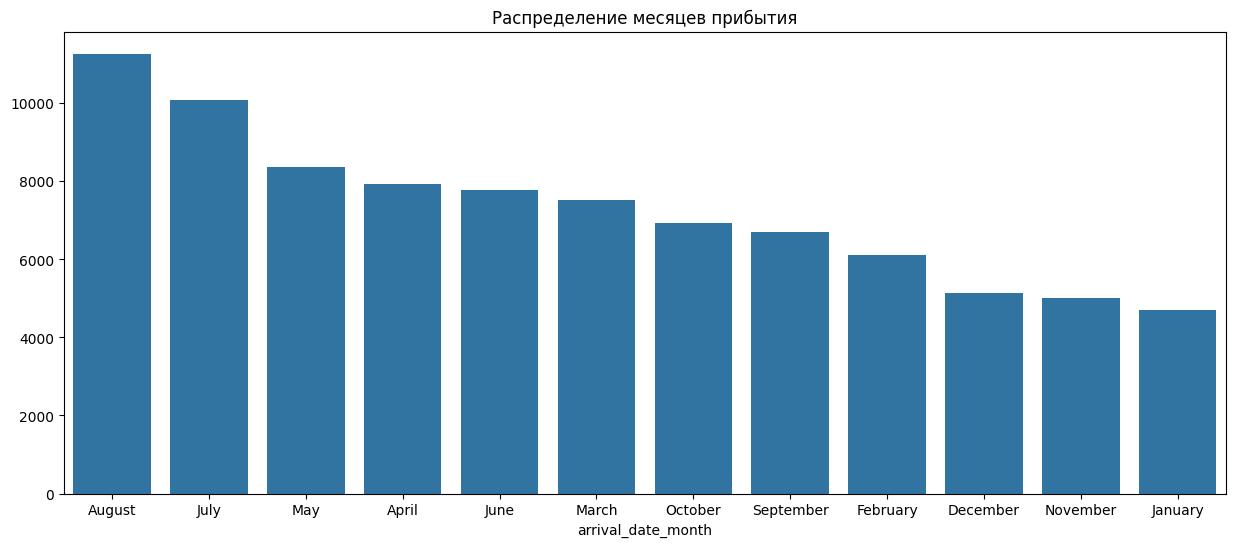

In [135]:
plt.figure(figsize=(15,6))
plt.title('Распределение месяцев прибытия')
sns.barplot(x=df['arrival_date_month'].value_counts().index, y=df['arrival_date_month'].value_counts().values)
plt.show()

Самыми популярнымы оказались летние и вессение месяцы, возможно, из-за наличия Resort Hotel и в целом популярности туризма в более теплые времена года - они доминируют.

##### arrival_date_week_number
Номер недели прибытия

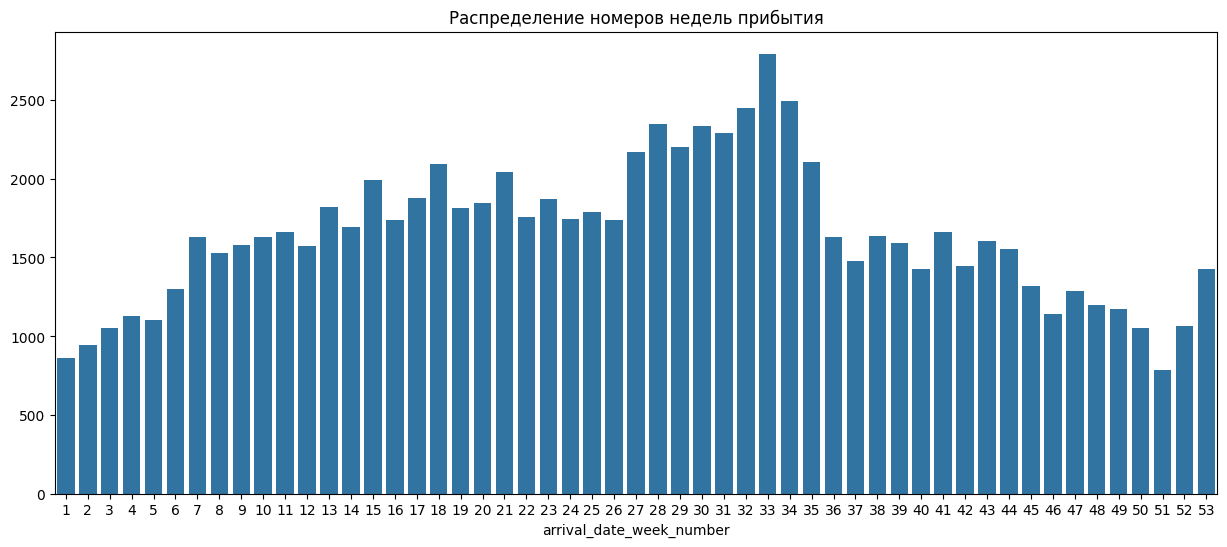

In [136]:
plt.figure(figsize=(15,6))
plt.title('Распределение номеров недель прибытия')
sns.barplot(x=df['arrival_date_week_number'].value_counts().index, y=df['arrival_date_week_number'].value_counts().values)
plt.show()

 По этому графику также видно, что около 30-ой недели (июль-август) - как раз такая же доминация этих недель в летнее время, что было видно и на анализе месяцев. Но номер недели вряд ли нам будет нужен для анализа - его можно удалить.

In [137]:
df = df.drop(columns={'arrival_date_week_number'})

##### arrival_date_day_of_month
День прибытия

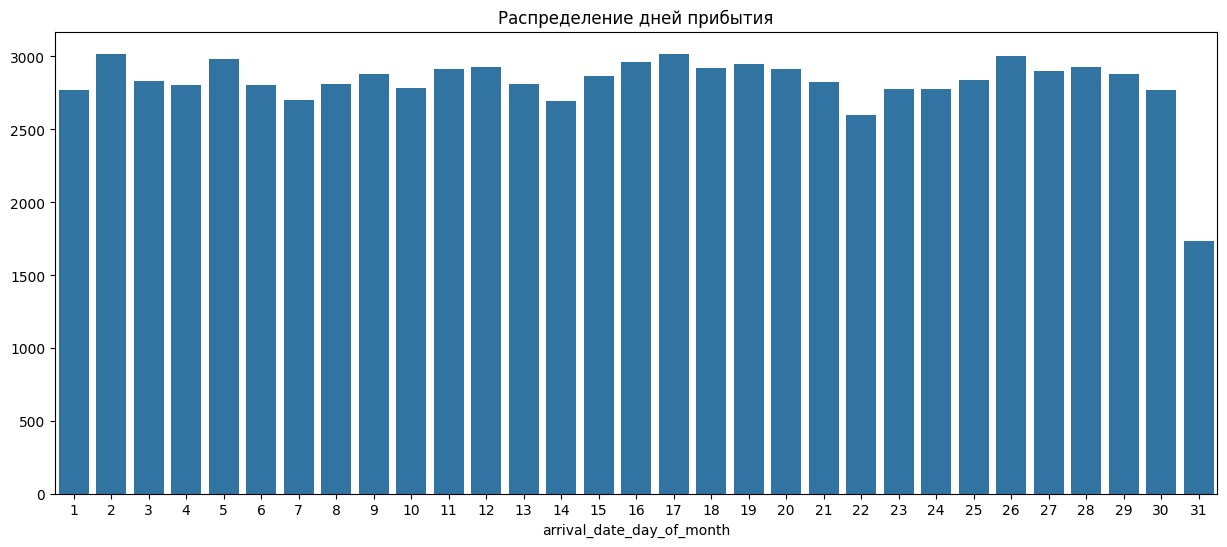

In [138]:
plt.figure(figsize=(15,6))
plt.title('Распределение дней прибытия')
sns.barplot(x=df['arrival_date_day_of_month'].value_counts().index, y=df['arrival_date_day_of_month'].value_counts().values)
plt.show()

В целом во все дни примерно одинаковое количество прибытий, кроме 31 числа - таких месяцев просто меньше чем других

Следующие признаки также связы с датой, но теперь и заезда и выезда. При этом в датасете нет колонки с простой датой заезда и датой выезда. Возмиожно, так лучше, к примеру, для модели ML, но, скорее всего, нам придется вывести даты заезда и выезда самим. В любом случае посмотрим на следующие признаки.

#### stays_in_weekend_nights
Количество ночей выходных дней, в которые гости жили/бронировали

#### stays_in_week_nights
Количество ночей будних дней, в которые гости жили/бронировали

In [139]:
df['stays_in_weekend_nights'].value_counts()

stays_in_weekend_nights
0     35151
2     26414
1     22657
4      1734
3      1150
6       113
5        70
8        60
7        15
9        10
10        7
12        5
13        3
16        3
14        2
18        1
19        1
Name: count, dtype: int64

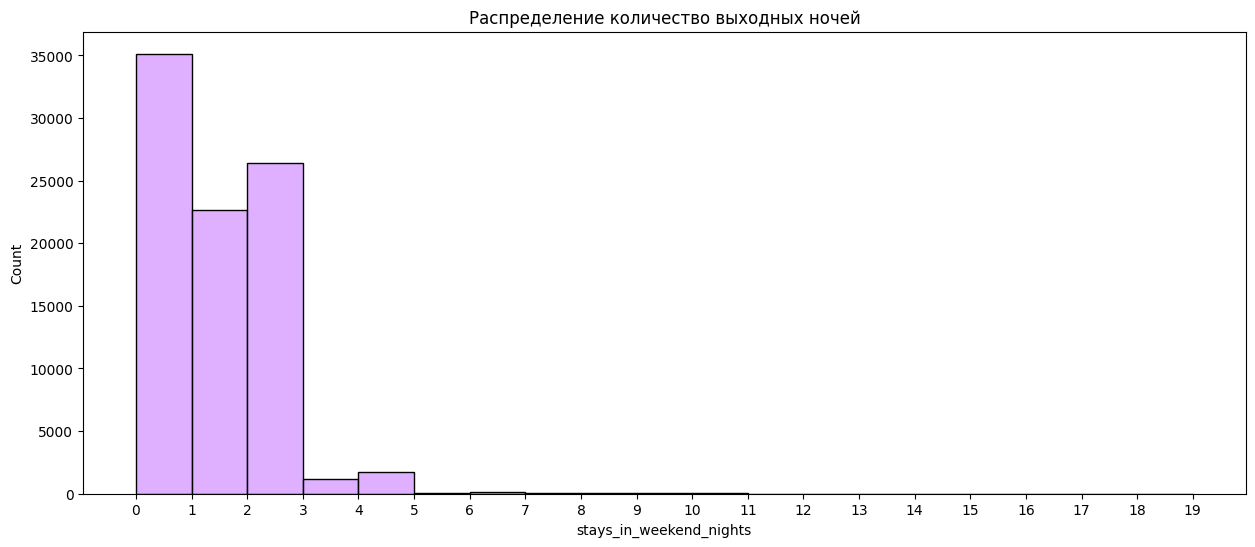

In [140]:
plt.figure(figsize=(15,6))
plt.title('Распределение количество выходных ночей')
sns.histplot(df, x='stays_in_weekend_nights', bins=19, color='#d596ff')
plt.xticks(range(0, 20))
plt.show()

Большая часть бронирований, где 0-2 выходных было проведено в отеле, то есть большая часть их них были бронивания в пределах недели, при этом 2 выходных популярнее одного выходного - значит люди чаще остаются уже на оба выходных дня, либо же, что еще популярнее, просто приезжают в рабочую неделю.

In [141]:
df['stays_in_week_nights'].value_counts().sort_index()

stays_in_week_nights
0      6175
1     22191
2     20744
3     16259
4      7874
5      9663
6      1379
7       967
8       613
9       219
10      972
11       50
12       40
13       27
14       25
15       68
16       13
17        4
18        6
19       21
20       41
21       15
22        7
24        2
25        6
26        1
30        5
32        1
33        1
34        1
35        1
40        2
41        1
42        1
50        1
Name: count, dtype: int64

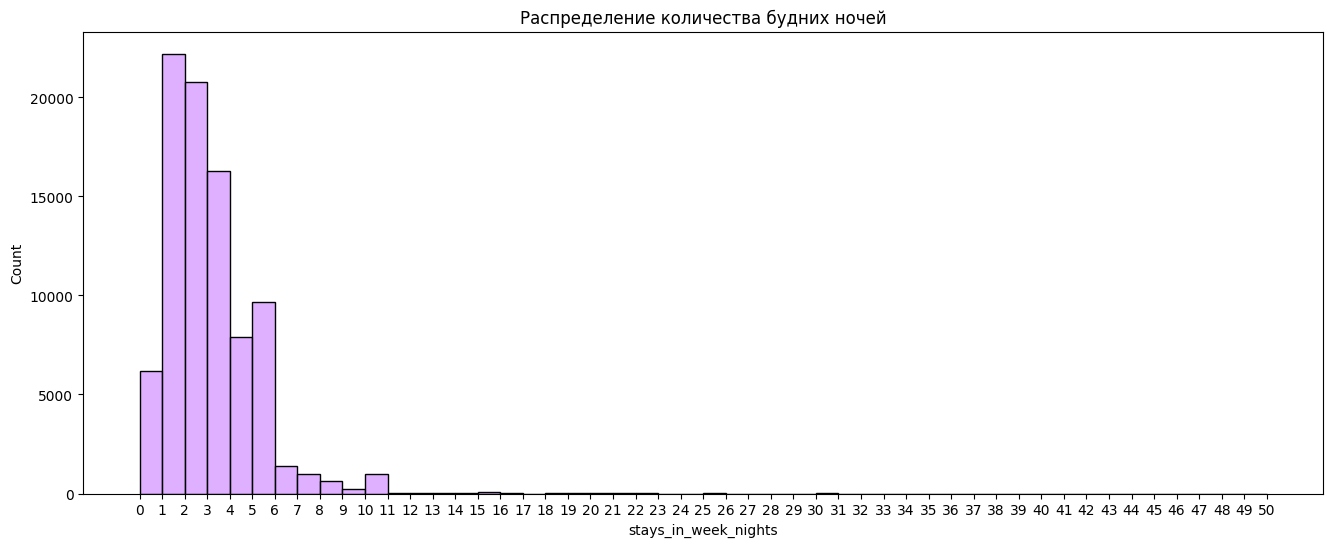

In [142]:
plt.figure(figsize=(16,6))
plt.title('Распределение количества будних ночей')
sns.histplot(df, x='stays_in_week_nights', bins=50, color='#d596ff')
plt.xticks(range(0, 51))
plt.show()

Здесь также видно, что большая часть бронирований в пределах недели, причем взяв во внимание крайне большие значения в обоих признаков - бывают бронирования очень долгие, надо будет еще далее посмотреть - это отмененные все бронирования или же они действительно были выполнены.

Сделаем новые колонки с общим количеством ночей и наличием выходных ночей

In [143]:
df['stays_in_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

In [144]:
df['has_weekend_nights'] = 0
df.loc[df['stays_in_weekend_nights'] > 0, 'has_weekend_nights'] = 1

In [145]:
df = df.drop(columns={'stays_in_week_nights', 'stays_in_weekend_nights'})

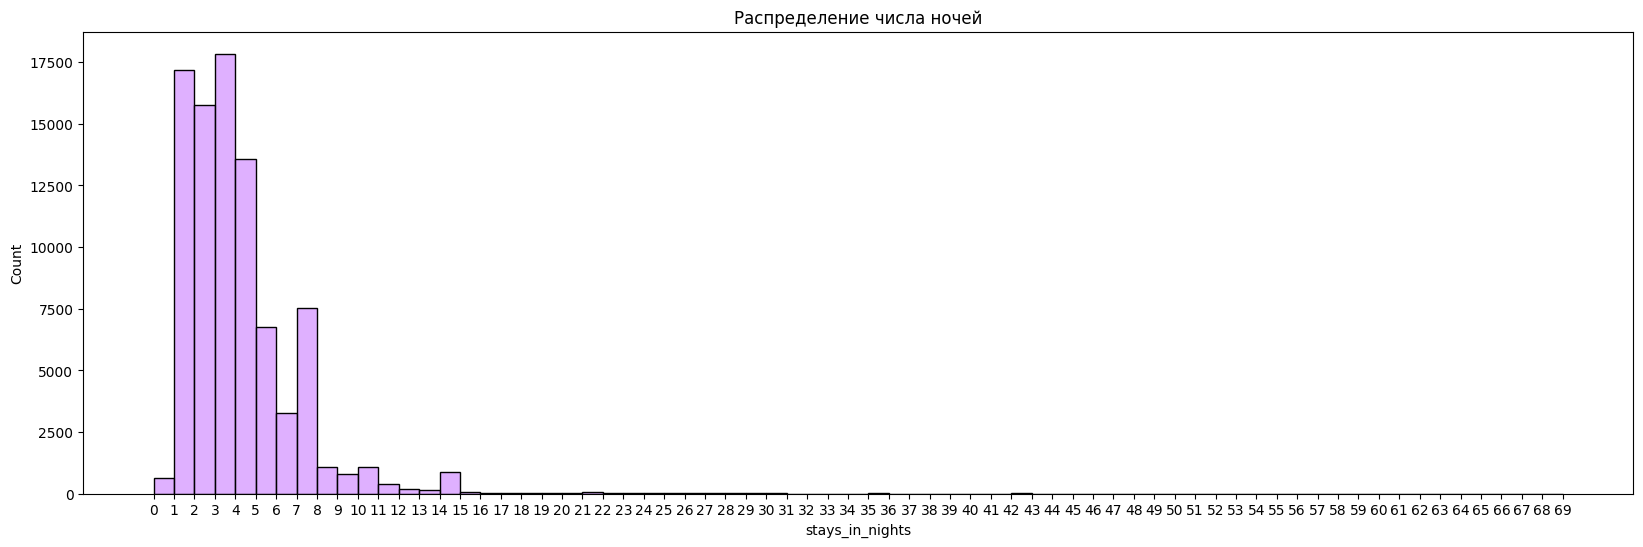

In [146]:
plt.figure(figsize=(20,6))
plt.title('Распределение числа ночей')
sns.histplot(df, x='stays_in_nights', bins=df['stays_in_nights'].max(), color='#d596ff')
plt.xticks(range(0, df['stays_in_nights'].max() + 1))
plt.show()

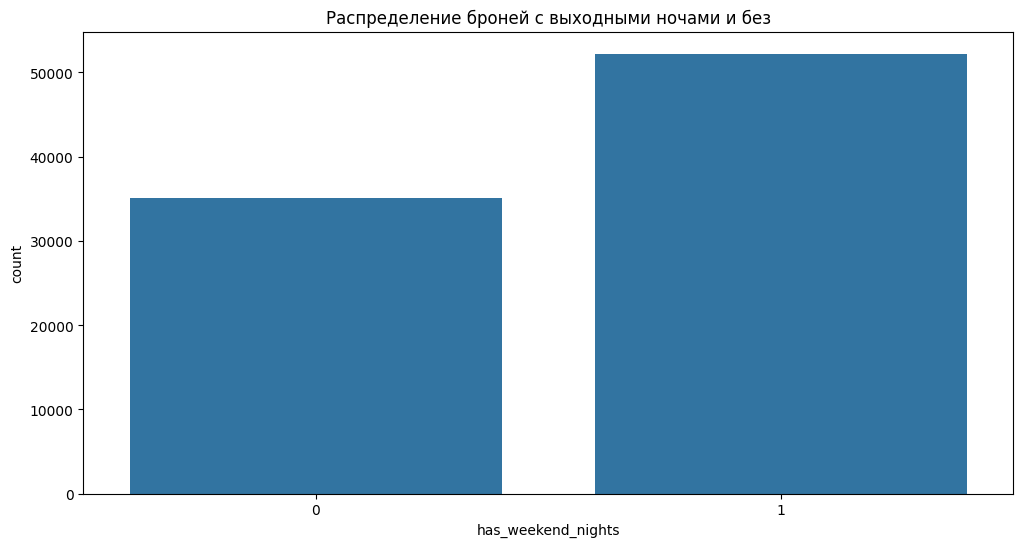

In [147]:
plt.figure(figsize=(12,6))
plt.title('Распределение броней с выходными ночами и без')
sns.barplot(df['has_weekend_nights'].value_counts())
plt.show()

Больше бронирований с наличием выходных, но и чисто в будние дни их немало.

Сделующие признаки характеризуют состав гостей, а именно наличие взрослых, детей и младенцев
#### adults

In [148]:
print(f'Пропусков у признака adults: {df['adults'].isnull().sum()}')

Пропусков у признака adults: 0


In [149]:
df['adults'].value_counts().sort_index()

adults
0       385
1     16503
2     64497
3      5935
4        60
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

Чаще всего, что логично, приезжают парой, из интересного - бронирования по 10, 20 и даже по 50 и 55 человек - посмотрим их

In [150]:
df[df['adults'] >= 10]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,stays_in_nights,has_weekend_nights
1539,Resort Hotel,1,304,2015,September,3,40,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02,3,0
1587,Resort Hotel,1,333,2015,September,5,26,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02,7,1
1643,Resort Hotel,1,336,2015,September,7,50,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-18,3,1
1752,Resort Hotel,1,340,2015,September,12,26,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02,7,1
1884,Resort Hotel,1,347,2015,September,19,26,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02,7,1
1917,Resort Hotel,1,349,2015,September,21,27,0.0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02,4,1
1962,Resort Hotel,1,352,2015,September,24,27,0.0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02,4,1
2003,Resort Hotel,1,354,2015,September,26,26,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02,7,1
2164,Resort Hotel,1,361,2015,October,3,26,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02,7,1
2173,Resort Hotel,1,338,2015,October,4,55,0.0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02,2,1


Все бронирования тут это сентябрь - октябрь 2015. При этом почти все забронированы, скорее всего, одним человеком/тур агентством, где последнее изменение статуса - 2 января 2015, кроме пары исключений и все они в итоге отменены. Наверное кто-то либо так сильно ошибся, либо это были автоматические действия.

Можем предположить, что если ни одно бронирование не было выполнено с числом взрослых от 10 и более, то эти странные бронирования есть смысл удалить, т.к. из-за ряда причин очень маловероятно, что все эти брони могли бы быть реализованы. Единственное, оставим брони, которые были сделаны не 2 января.

In [151]:
df = df[~((df['adults'] >= 10) & (df['reservation_status_date'] == '2015-01-02'))]

In [152]:
df[df['adults'] >= 10]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,stays_in_nights,has_weekend_nights
1643,Resort Hotel,1,336,2015,September,7,50,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-18,3,1
2228,Resort Hotel,1,328,2015,October,6,20,0.0,0,BB,PRT,Direct,Direct,0,0,0,D,D,1,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-09-03,7,1


#### children

In [153]:
print(f'Пропусков у признака children: {df['children'].isnull().sum()}')

Пропусков у признака children: 4


У нас нашлись 4 пропуска, посмотрим их

In [154]:
pd.options.display.max_columns = None # https://ru.hexlet.io/qna/data-analytics/questions/pandas-kak-vyvodit-vse-stolbtsy
df[df['children'].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,stays_in_nights,has_weekend_nights
40600,City Hotel,1,2,2015,August,3,2,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01,1,1
40667,City Hotel,1,1,2015,August,5,2,NaN,0,BB,PRT,Direct,Undefined,0,0,0,B,B,0,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04,2,0
40679,City Hotel,1,1,2015,August,5,3,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04,2,0
41160,City Hotel,1,8,2015,August,13,2,NaN,0,BB,PRT,Online TA,Undefined,0,0,0,B,B,0,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09,7,1


Во-первых видно два бронирования с общими датами, которые в итоге отменены, как и два других бронивания. Хотя и точь-в-точь по другим признаков они не одинаковые. Возможно, они были внесены в базу с ошибкой. Не будем выкидывать эти пропуски, а просто заполним нулем - самым популярным значением (будет видно ниже), предполоагая, что они собирались приехать без детей.

In [155]:
df['children'] = df['children'].fillna(0)
print(f'Пропусков у признака children: {df['children'].isnull().sum()}')

Пропусков у признака children: 0


In [156]:
pd.concat([df['children'].value_counts().sort_index(), df['children'].value_counts().sort_index() / df.shape[0] * 100], axis=1)

,count,count
children,,
0.0,79021,90.428563
1.0,4695,5.372776
2.0,3593,4.111690
3.0,75,0.085827
10.0,1,0.001144


Видно, что отели без семейного уклона, каким мог бы быть тот же Resort Hotel. 90% брониваний - без детей.

#### babies

In [157]:
print(f'Пропусков у признака babies: {df['babies'].isnull().sum()}')

Пропусков у признака babies: 0


In [158]:
pd.concat([df['babies'].value_counts().sort_index(), df['babies'].value_counts().sort_index() / df.shape[0] * 100], axis=1)

,count,count
babies,,
0,86471,98.954054
1,897,1.026492
2,15,0.017165
9,1,0.001144
10,1,0.001144


Почти 99% брониваний без младенцев, но есть два интересных случая, где в бронировании 9 и 10 младенцев. Посмотрим на эти 2 брони.

In [159]:
df[df['babies'] >= 9]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,stays_in_nights,has_weekend_nights
46619,City Hotel,0,37,2016,January,12,2,0.0,10,BB,PRT,Online TA,TA/TO,0,0,0,D,D,1,No Deposit,9.0,NaN,0,Transient,84.45,0,1,Check-Out,2016-01-14,2,0
78656,City Hotel,0,11,2015,October,11,1,0.0,9,BB,GBR,Corporate,Corporate,0,0,0,A,B,1,No Deposit,95.0,NaN,0,Transient-Party,95.00,0,0,Check-Out,2015-10-14,3,1


Эти две брони, на удивление, не отменены, причем одно из бронирований с 1 взрослым на 9 детей.

#### Выделим категории гостей исходя из данных признаков adults, children, babies

- Solo - один взрослый
- Couple - два взрослых
- With kids - взрослые с детьми
- Group - группа взрослых
- Only kids - только дети

In [160]:
df['kids'] = df['children'] + df['babies']

def guests_categories(x):
    if x['kids'] == 0 and x['adults'] == 1:
        return 'Solo'
    elif x['kids'] == 0 and x['adults'] == 2:
        return 'Couple'
    elif x['kids'] > 0 and x['adults'] > 0:
        return 'With kids'
    elif x['kids'] == 0 and x['adults'] > 2:
        return 'Group'
    elif x['kids'] > 0 and x['adults'] == 0:
        return 'Only kids'

df['guests_categories'] = df.apply(guests_categories, axis=1)
pd.concat([df['guests_categories'].value_counts(), df['guests_categories'].value_counts() / df.shape[0] * 100], axis=1)

,count,count
guests_categories,,
Couple,56582,64.750243
Solo,16068,18.387595
With kids,8884,10.166505
Group,5466,6.255078
Only kids,219,0.250615


Заметим, что большая часть гостей - это пары по два человека, при этом были случаи и бронирований исключительно с детьми. Старые колонки удалим.

In [161]:
df = df.drop(columns={'adults', 'kids', 'children', 'babies'})

Также заметим, что бронирования только с детьми у нас составляют всего 0.25% от выборки, при это далее ~~спойлер~~ мы будем сравнивать эти категории между собой и в этих сравнениях данная группа нам вряд ли что-то скажет и на выборку почти влиять не будет.

In [162]:
df = df[df['guests_categories'] != 'Only kids']

#### meal
Признак, указывающий на выбранный тип питания. Обратимся к описанию категорий с информации о датасете на kaggle:
- Undefined/SC – no meal package;
- BB – Bed & Breakfast;
- HB – Half board (breakfast and one other meal – usually dinner);
- FB – Full board (breakfast, lunch and dinner)

In [163]:
print(f'Пропусков у признака meal: {df['meal'].isnull().sum()}')

Пропусков у признака meal: 0


In [164]:
df['meal'].value_counts()

meal
BB           67757
SC            9479
HB            9078
Undefined      492
FB             360
Name: count, dtype: int64

Можем заметить, что Undefined и SC, судя по описанию - один и тот же вариант. Переименуем в таком случае Undefined на SC

In [165]:
df.loc[df['meal'] == 'Undefined', 'meal'] = 'SC'

In [166]:
df['meal'].value_counts()

meal
BB    67757
SC     9971
HB     9078
FB      360
Name: count, dtype: int64

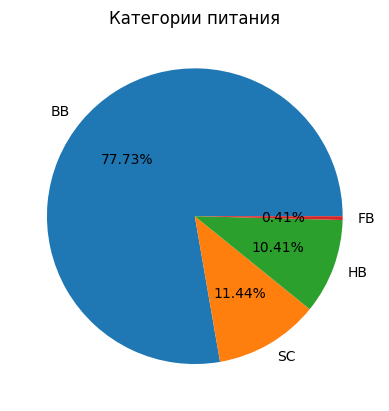

In [167]:
plt.figsize=(8, 6)

plt.title('Категории питания')
plt.pie(df['meal'].value_counts(), labels=df['meal'].value_counts().index, autopct='%.2f%%')

plt.show()

Большая часть бронирований - только завтраки. Бронирований с тремя приемами еды - вообще меньше процента. Вряд ли этот признак будет полезен в рамках нашего анализа. Удалим его.

In [168]:
df = df.drop(columns={'meal'})

#### country
Этот признак - страна происхождения бронировавших. Судя по описанию на kaggle категории представлены в формате ISO 3155–3:2013, хотя загуглив его - ИИ от гугла в поиске говорит, что такого формата нет и, возможно, имелось в виду ISO 3166-3. Но посмотрим еще далее, для начала проверим наличие пропусков.

In [169]:
print(f'Пропусков у признака country: {df['country'].isnull().sum()}')

Пропусков у признака country: 452


У нас достаточно много пропусков в country. Выведем рандомные 10

In [170]:
df[df['country'].isna()].sample(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,stays_in_nights,has_weekend_nights,guests_categories
14136,Resort Hotel,0,0,2016,March,15,NaN,Direct,Direct,0,0,0,A,A,1,No Deposit,NaN,NaN,0,Transient,40.00,0,0,Check-Out,2016-03-16,1,0,Couple
14615,Resort Hotel,0,176,2016,August,20,NaN,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,196.0,NaN,0,Transient,143.00,0,1,Check-Out,2016-08-25,5,1,With kids
14499,Resort Hotel,0,0,2016,February,15,NaN,Offline TA/TO,TA/TO,0,0,1,A,D,0,No Deposit,NaN,NaN,0,Transient,40.00,0,0,Check-Out,2016-02-16,1,1,Solo
14091,Resort Hotel,0,0,2015,December,3,NaN,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,38.00,0,0,Check-Out,2015-12-04,1,0,Solo
14629,Resort Hotel,0,3,2016,March,15,NaN,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,60.00,0,1,Check-Out,2016-03-20,5,0,Couple
13974,Resort Hotel,0,7,2017,April,5,NaN,Corporate,Corporate,0,0,2,A,G,0,No Deposit,NaN,178.0,0,Transient,48.00,0,0,Check-Out,2017-04-06,1,0,Solo
14116,Resort Hotel,0,29,2016,November,11,NaN,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,6.0,NaN,0,Transient,42.08,0,1,Check-Out,2016-11-13,2,0,Group
14625,Resort Hotel,0,7,2017,April,17,NaN,Online TA,TA/TO,0,0,0,A,D,0,No Deposit,468.0,NaN,0,Transient-Party,72.16,0,0,Check-Out,2017-04-18,1,1,Solo
14360,Resort Hotel,0,0,2016,October,17,NaN,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,200.0,0,Transient,45.00,0,0,Check-Out,2016-10-18,1,1,Solo
14370,Resort Hotel,0,1,2016,June,30,NaN,Direct,Direct,0,0,0,A,E,0,No Deposit,NaN,51.0,0,Transient,79.00,1,0,Check-Out,2016-07-01,1,0,Couple


Пока подумаем, что с ними сделать. Пока посмотрим как в итоге выглядят обозначения стран.

In [171]:
df['country'].value_counts()[0:10]

country
PRT    27399
GBR    10418
FRA     8812
ESP     7238
DEU     5374
ITA     3057
IRL     3012
BEL     2065
BRA     1985
NLD     1902
Name: count, dtype: int64

Здесь мы видим трехбуквенные (самые распространенные) обозначения стран (хотя этот ISO 3155–3:2013 - четырехбуквенные, причем стран, которых уже не существует, как к примеру - СССР это будет SUHH). Скорее всего еще одна ошибочка в описании и это на деле ISO 3166-1. Посмотрим на соотношение топ 5 категорий и остальных, при этом в более понятный вид расшифруем эти 5 стран:
- PRT - Португалия
- GBR - Великобритания
- FRA - Франция
- ESP - Испания
- DEU - Германия

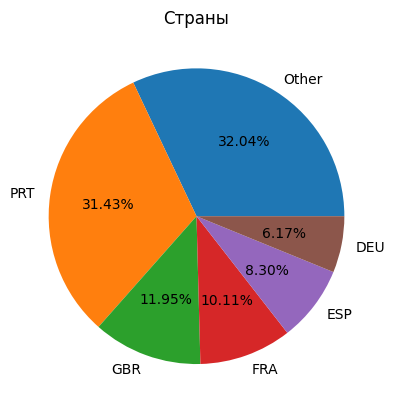

In [172]:
plt.figsize=(8, 6)

df_changed_countries = df.copy()
df_changed_countries.loc[~df['country'].isin(['PRT', 'GBR', 'FRA', 'ESP', 'DEU']), 'country'] = 'Other'

plt.title('Страны')
plt.pie(df_changed_countries['country'].value_counts(), labels=df_changed_countries['country'].value_counts().index, autopct='%.2f%%')

plt.show()

Можем заметить, что большая часть у нас из Португалии - почти треть выборки. Далее еще ряд крупных европейских государств. Можем предположить, что отель находится в Португалии - из-за чего и число бронирований оттуда наибольшее.

И давайте заполним пропуски самой популярной - Португалией.

In [173]:
df['country'] = df['country'].fillna('PRT')
print(f'Пропусков у признака country: {df['country'].isnull().sum()}')

Пропусков у признака country: 0


#### market_segment
Обозначение сегмента рынка. Описание на kaggle говорит, только о паре расшифровок: “TA” - “Турагенства", “TO” это “Туроператоры", остальное посмотрим сами.

Перед этим, как и везде, проверим признак на наличие пропусков.

In [174]:
print(f'Пропусков у признака market_segment: {df['market_segment'].isnull().sum()}')

Пропусков у признака market_segment: 0


In [175]:
df['market_segment'].value_counts()

market_segment
Online TA        51435
Offline TA/TO    13881
Direct           11769
Groups            4942
Corporate         4212
Complementary      698
Aviation           227
Undefined            2
Name: count, dtype: int64

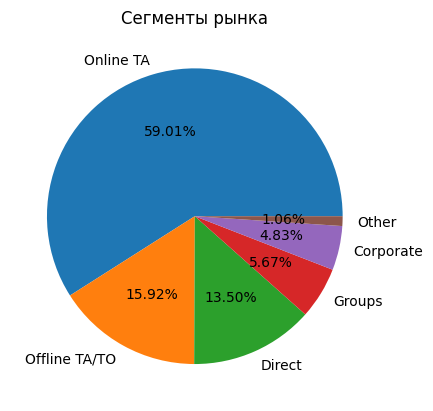

In [176]:
plt.figsize=(8, 6)

df_changed_market_segment = df.copy()
df_changed_market_segment.loc[~df['market_segment'].isin(['Online TA', 'Offline TA/TO', 'Direct', 'Groups', 'Corporate']), 'market_segment'] = 'Other'

plt.title('Сегменты рынка')
plt.pie(df_changed_market_segment['market_segment'].value_counts(), labels=df_changed_market_segment['market_segment'].value_counts().index, autopct='%.2f%%')

plt.show()

Популярнее всех - онлайн и оффлайн турагенства и, для оффлайна, еще напрямую туроператоры, далее Direct - видимо прямые брони, и более менее долю еще занимают Groups - группы и Corporate - корпоративные. В целом распределение логичное, ничего аномального. Есть правда еще два бронирования с фактически пропуском, просто заполненным значением Undefined. Можем объединение в Other, которое мы брали для графика - сохранить в сам датасет, туда же попадет undefined и прочие малочисленные категории, которые вряд ли можно по отдельно рассмотреть из-за их размера.

In [177]:
df.loc[~df['market_segment'].isin(['Online TA', 'Offline TA/TO', 'Direct', 'Groups', 'Corporate']), 'market_segment'] = 'Other'

#### distribution_channel
Этот признак - канал распространения бронирования, в описании на kaggle там также добавлено про расшифровку TO и TA - что намекает нам на похожие категории, что и в прошлом признаке.

In [178]:
print(f'Пропусков у признака distribution_channel: {df['distribution_channel'].isnull().sum()}')

Пропусков у признака distribution_channel: 0


In [179]:
df['distribution_channel'].value_counts()

distribution_channel
TA/TO        68950
Direct       12949
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64

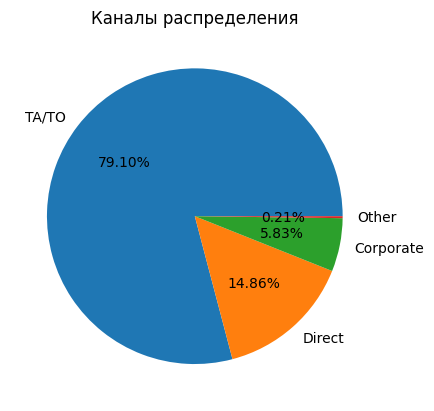

In [180]:
plt.figsize=(8, 6)

df_changed_distribution_channel = df.copy()
df_changed_distribution_channel.loc[~df['distribution_channel'].isin(['TA/TO', 'Direct', 'Corporate']), 'distribution_channel'] = 'Other'

plt.title('Каналы распределения')
plt.pie(df_changed_distribution_channel['distribution_channel'].value_counts(), labels=df_changed_distribution_channel['distribution_channel'].value_counts().index, autopct='%.2f%%')

plt.show()

Можно заметить действильно схожесть с прошлым признаком. Если мы объединим число бронированием с сегментам 'Online TA', 'Offline TA/TO', 'Groups', то выйдет около 80,62% и здесь у нас TA/TO 79.12% - просто добавились туда еще группы, которые логично, что оформлялись через какого-то тур оператора. Доля Dircet и Corporate также примерно одинаковые. Давайте также все остальное заменим на Other.

In [181]:
df.loc[~df['distribution_channel'].isin(['TA/TO', 'Direct', 'Corporate']), 'distribution_channel'] = 'Other'

#### Признак is_repeated_guest
Что значит?
- он говорит бронировал ли клиент ранее отель, либо брониурет этот отель впервые
- он бинарный
- потенциально важный признак, можно будет использовать потом для оценки лояльности, удовлетворительности, возможно реже будут отменять

In [182]:
df['is_repeated_guest'].isna().sum() #пропусков нет

np.int64(0)

In [183]:
df['is_repeated_guest'].unique() #только 0 и 1, бинарный

array([0, 1])

In [184]:
df['is_repeated_guest'].value_counts()

is_repeated_guest
0    83752
1     3414
Name: count, dtype: int64

Практически все гости впервые бронировали, около 4 процентов только (3415 гостей) бронировали не в первый раз. Дисбаланс довольно сильный, так что сложно будет сравнивать эти категории, так что удалим этот признак.

In [185]:
df = df.drop(columns={'is_repeated_guest'})

#### Признак previous_cancellations
Что значит?
- он показывает, сколько бронирований гость уже отменил до этого бронирования
- потенциально неплохой признак, потому что он может быть связан с поведением гостя, если отменял - может и сейчас отменить

In [186]:
df['previous_cancellations'].isna().sum() #нет пропусков

np.int64(0)

In [187]:
df['previous_cancellations'].value_counts()

previous_cancellations
0     85483
1      1405
2       112
3        61
4        30
11       27
5        19
6        17
13        4
25        2
24        2
26        1
14        1
19        1
21        1
Name: count, dtype: int64

Очень мало не нулей, в целом можно приравнять все, что >0 к 1, чтобы не засорять и было читаемее

In [188]:
df['previous_cancellations'] = (df['previous_cancellations'] > 0).astype(int) #astype чтобы маску из тру фолс убрать
df['previous_cancellations'].unique()

array([0, 1])

In [189]:
df['previous_cancellations'].value_counts()

previous_cancellations
0    85483
1     1683
Name: count, dtype: int64

Попробуем сейчас провизуализировать какую-то связь с отменой бронирования

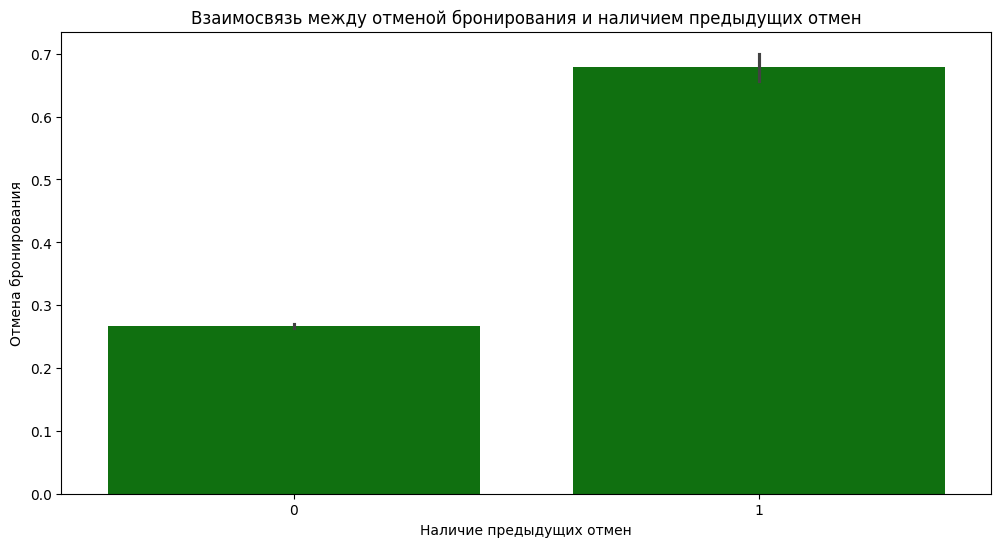

In [190]:
plt.figure(figsize=(12,6))
sns.barplot(df, x = 'previous_cancellations', y = 'is_canceled', color= 'green')

plt.title('Взаимосвязь между отменой бронирования и наличием предыдущих отмен')
plt.xlabel('Наличие предыдущих отмен')
plt.ylabel('Отмена бронирования')
plt.show()

Замечаем, что если раньше была хотя бы 1 отмена, выше количество текущих отмен бронирования. Держим это в голове, далее можно будет проверить на статистическом уровне

### Признак previous_bookings_not_canceled
Что значит?
- показывает кол-во предыдущих бронирований, которые не были отменены

In [191]:
df['previous_bookings_not_canceled'].isna().sum() #net

np.int64(0)

In [192]:
df['previous_bookings_not_canceled'].value_counts() #объединяем

previous_bookings_not_canceled
0     83622
1      1481
2       580
3       331
4       228
      ...  
68        1
69        1
70        1
71        1
72        1
Name: count, Length: 73, dtype: int64

In [193]:
df['previous_bookings_not_canceled'] = (df['previous_bookings_not_canceled'] >0).astype(int)
df['previous_bookings_not_canceled'].unique()

array([0, 1])

In [194]:
df['previous_bookings_not_canceled'].value_counts()

previous_bookings_not_canceled
0    83622
1     3544
Name: count, dtype: int64

Очень большой дисбаланс, маловероятно, что получится что-то отсюда вытащить

### Признак reserved_room_type
Что значит?
- показывает тип комнаты, который забронировал человек

In [195]:
df['reserved_room_type'].unique()

<StringArray>
['C', 'A', 'D', 'E', 'G', 'F', 'H', 'L', 'P', 'B']
Length: 10, dtype: str

In [196]:
df['reserved_room_type'].isna().sum() #нет

np.int64(0)

In [197]:
df['reserved_room_type'].value_counts()

reserved_room_type
A    56534
D    17396
E     6047
F     2821
G     2051
C      915
B      794
H      596
L        6
P        6
Name: count, dtype: int64

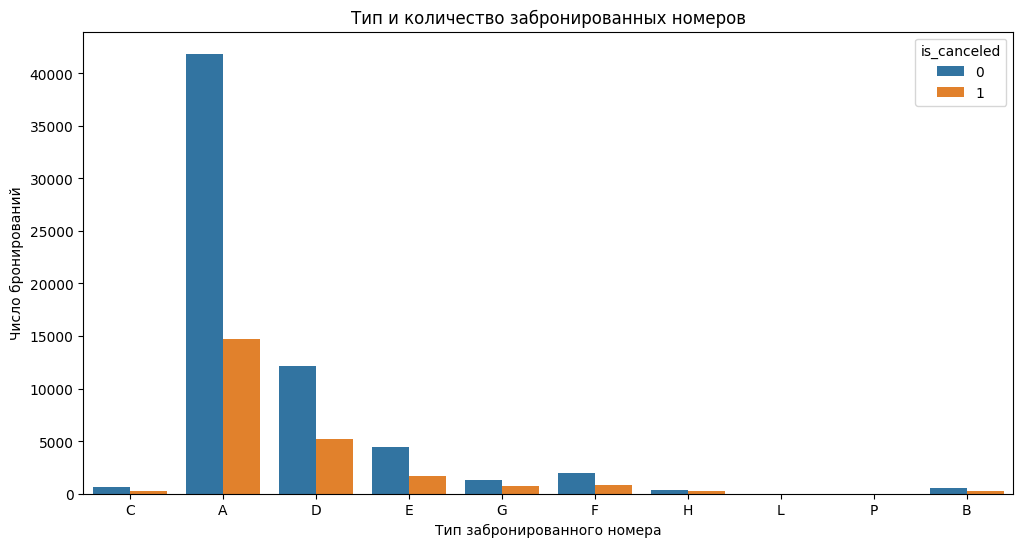

In [198]:
plt.figure(figsize=(12,6))
sns.countplot(df, x= 'reserved_room_type', hue= 'is_canceled')

plt.title('Тип и количество забронированных номеров')
plt.xlabel('Тип забронированного номера')
plt.ylabel('Число бронирований')
plt.show()

Больше всего забронированных номеров - тип А и D. Но это нам мало что дает, потому что - это зашифрованные названия типов номеров, что было сделано ради обеспечения анонимности (по описанию на Kaggle). Там что удалим этот признак.

In [199]:
df = df.drop(columns={'reserved_room_type'})

### Признак assigned_room_type
Что значит?
- показывает тип комнаты, который человек реально получил при заселении

In [200]:
df['assigned_room_type'].isna().sum() #нет

np.int64(0)

In [201]:
df['assigned_room_type'].value_counts()

assigned_room_type
A    46268
D    22428
E     7194
F     3627
G     2497
C     2165
B     1641
H      706
I      357
K      276
P        6
L        1
Name: count, dtype: int64

Те же типы, также не получится использовать, как и прошлый признак. Соответственно, его тоже удалим.

In [202]:
df = df.drop(columns={'assigned_room_type'})

### Признак booking_changes
Что значит?
- Сколько раз клиент изменял свое бронирование до финального статуса

In [203]:
df['booking_changes']

0         3
1         4
2         0
3         0
4         0
         ..
119385    0
119386    0
119387    0
119388    0
119389    0
Name: booking_changes, Length: 87166, dtype: int64

In [204]:
df['booking_changes'].isna().sum() #нет

np.int64(0)

In [205]:
df['booking_changes'].value_counts() #мало после 2, можно объединить

booking_changes
0     71320
1     10858
2      3502
3       871
4       356
5       115
6        59
7        30
8        17
9         8
10        6
13        5
14        5
15        3
17        2
16        2
12        2
11        2
20        1
21        1
18        1
Name: count, dtype: int64

In [206]:
df['booking_changes'] = df['booking_changes'].apply(lambda x :x if x < 3 else '>2')
df['booking_changes'].unique()

array(['>2', 0, 1, 2], dtype=object)

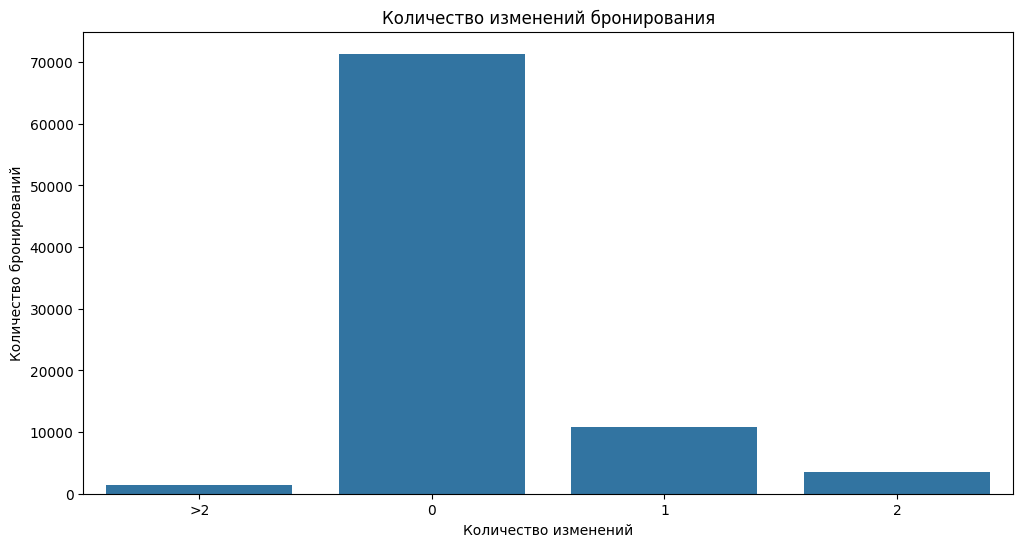

In [207]:
plt.figure(figsize=(12,6))
sns.countplot(df, x='booking_changes')

plt.title('Количество изменений бронирования')
plt.xlabel('Количество изменений')
plt.ylabel('Количество бронирований')
plt.show()

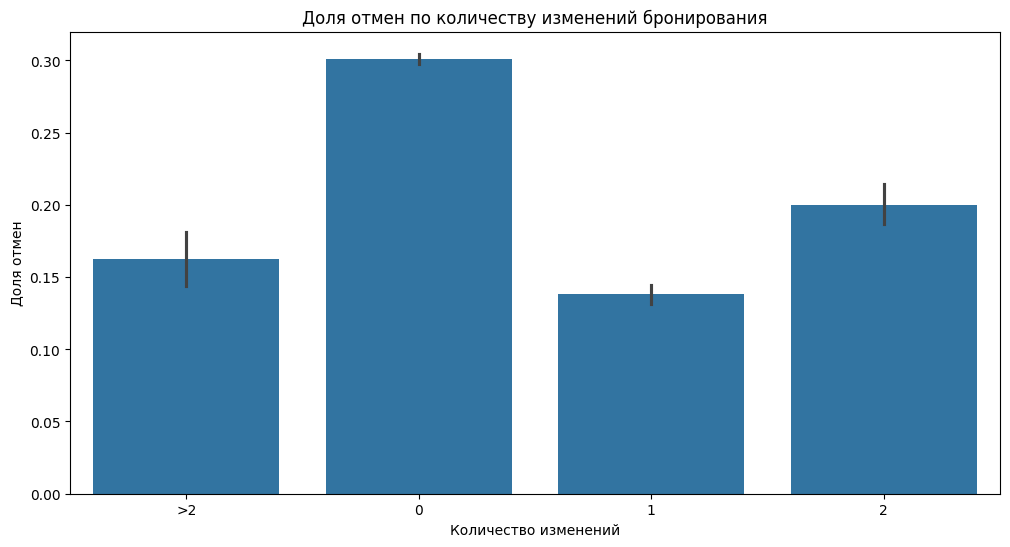

In [208]:
plt.figure(figsize=(12,6))
sns.barplot(df, x='booking_changes', y='is_canceled')

plt.title('Доля отмен по количеству изменений бронирования')
plt.xlabel('Количество изменений')
plt.ylabel('Доля отмен')
plt.show()

### Признак deposit_type
Что значит?
- какой тип депозита был у бронирования

In [209]:
df['deposit_type'].isna().sum() #net

np.int64(0)

In [210]:
df['deposit_type'].value_counts()

deposit_type
No Deposit    86021
Non Refund     1038
Refundable      107
Name: count, dtype: int64

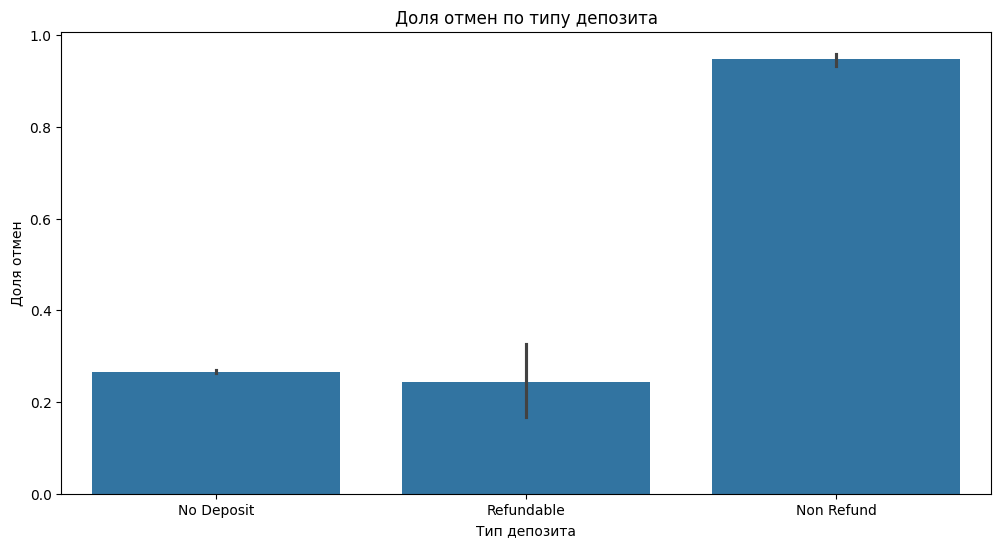

In [211]:
plt.figure(figsize=(12,6))
sns.barplot(df, x='deposit_type', y='is_canceled')

plt.title('Доля отмен по типу депозита')
plt.xlabel('Тип депозита')
plt.ylabel('Доля отмен')
plt.show()

Тут кажется неплохой вариант, по графику можно предположить, что тип депозита все таки влияет (можно статистически проверить), можно даже предположить, что к примеру non refund для каких то компаний рискованных. Но все это лучше будем проверять стат тестами

### Признак agent
Что значит?
- айди туристического агентсва, которое делало бронирование

Не особо полезный признак, удалим его

In [212]:
df = df.drop(columns = ['agent'])

### Признак company
- компания через которую было сделано бронирование

Весь в пропусках, удалим

In [213]:
df['company'].isna().sum()

np.int64(81909)

In [214]:
df = df.drop(columns = ['company'])

### Признак days_in_waiting_list
Что значит?
- сколько дней бронирование было в листе ожидания перед подтверждением

In [215]:
df['days_in_waiting_list'].isna().sum() #net

np.int64(0)

In [216]:
df['days_in_waiting_list'].value_counts() #объединим

days_in_waiting_list
0      86306
63        53
87        25
44        23
15        22
       ...  
81         1
92         1
74         1
167        1
36         1
Name: count, Length: 128, dtype: int64

In [217]:
df['days_in_waiting_list'] = (df['days_in_waiting_list'] > 0).astype(int)
df['days_in_waiting_list'].value_counts()

days_in_waiting_list
0    86306
1      860
Name: count, dtype: int64

Удалим, ничего интересного

In [218]:
df = df.drop(columns = ['days_in_waiting_list'])

### Признак customer_type
Что значит?
- показывает тип клиента
- Transient — обычный клиент
- Transient-Party — индивидуальный клиент, связанный с группой
- Contract — клиент по контракту
- Group — групповое бронирование

In [219]:
df['customer_type'].unique()

<StringArray>
['Transient', 'Contract', 'Transient-Party', 'Group']
Length: 4, dtype: str

In [220]:
df['customer_type'].isna().sum() #net

np.int64(0)

In [221]:
df['customer_type'].value_counts()

customer_type
Transient          71850
Transient-Party    11646
Contract            3138
Group                532
Name: count, dtype: int64

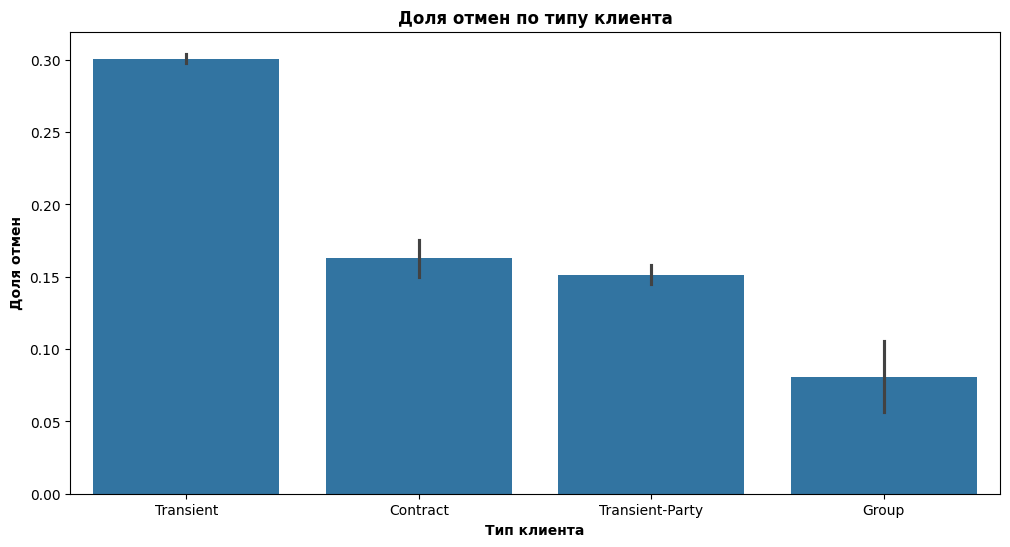

In [222]:
plt.figure(figsize=(12,6))
sns.barplot(df, x='customer_type', y='is_canceled')

plt.title('Доля отмен по типу клиента',fontweight='bold')
plt.xlabel('Тип клиента', fontweight='bold')
plt.ylabel('Доля отмен',fontweight='bold')

plt.show()

В целом логично, у многих индивидуальных меняются планы проще чем у каких то групповых бронированиях

### Признак adr
Что значит?
- средняя стоимость номера за ночь

In [223]:
df['adr'].isna().sum() #нет

np.int64(0)

In [224]:
df['adr'].describe() #есть и отрицательные числа

count    87166.000000
mean       106.414515
std         55.028371
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.100000
max       5400.000000
Name: adr, dtype: float64

In [225]:
df[df['adr'] <0] #он один, удалим

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,stays_in_nights,has_weekend_nights,guests_categories
14969,Resort Hotel,0,195,2017,March,5,GBR,Groups,Direct,0,1,2,No Deposit,Transient-Party,-6.38,0,0,Check-Out,2017-03-15,10,1,Couple


In [226]:
df = df.drop(index=14969)
df['adr'].sort_values()

0            0.0
21359        0.0
2242         0.0
14069        0.0
14052        0.0
           ...  
13142      450.0
103912     451.5
15083      508.0
111403     510.0
48515     5400.0
Name: adr, Length: 87165, dtype: float64

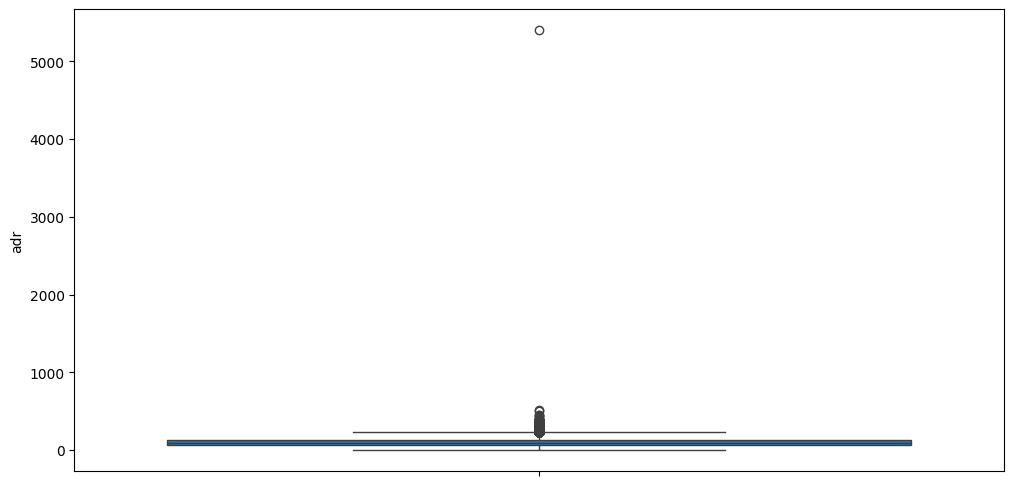

In [227]:
plt.figure(figsize=(12,6))
sns.boxplot(df['adr'])

plt.show()

In [228]:
df['adr'].sort_values(ascending = False) #вот он один выброс, либо ошибка либо наверное какой то нетипичный кейс

48515     5400.0
111403     510.0
15083      508.0
103912     451.5
13142      450.0
           ...  
79017        0.0
79016        0.0
79015        0.0
79014        0.0
0            0.0
Name: adr, Length: 87165, dtype: float64

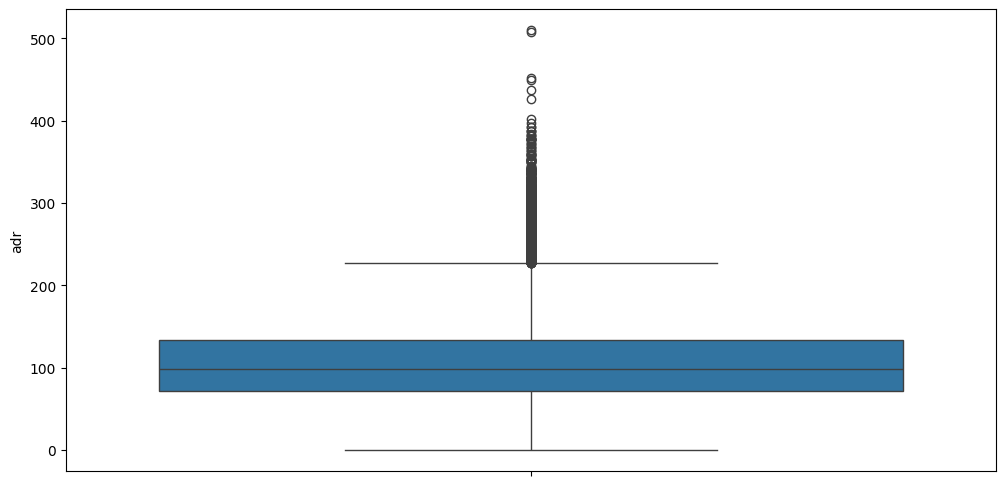

In [229]:
df = df[df['adr'] < 5000]
df['adr'].sort_values(ascending = False)

plt.figure(figsize=(12,6))
sns.boxplot(df['adr'])

plt.show()

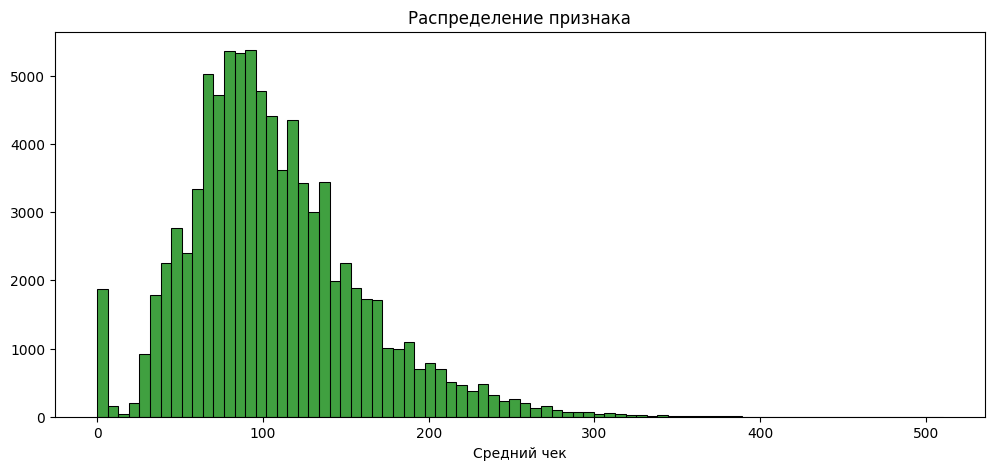

In [230]:
plt.figure(figsize=(12,5))
sns.histplot(df['adr'], bins=80, color = 'green')

plt.title('Распределение признака')
plt.xlabel('Средний чек')
plt.ylabel('')

plt.show()

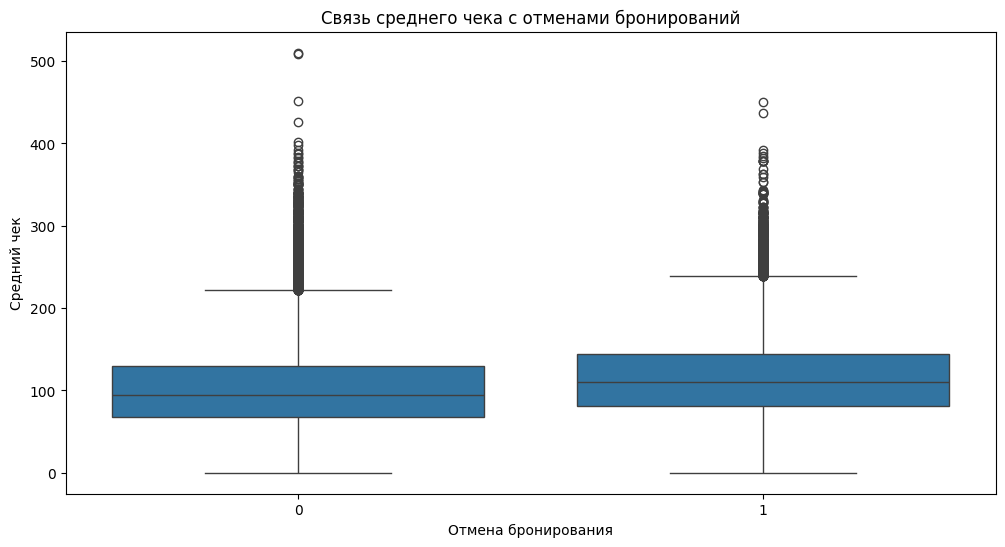

In [231]:
plt.figure(figsize=(12,6))
sns.boxplot(df, x='is_canceled', y='adr')

plt.title('Связь среднего чека с отменами бронирований')
plt.xlabel('Отмена бронирования')
plt.ylabel('Средний чек')

plt.show()

Можно заметить что у отмененных медианная значение среднего чека выше, можно вщять как потенциальный признак для стат теста

### Признак required_car_parking_spaces
Что значит?
- сколько парковочных мест запросил клиент

In [232]:
df['required_car_parking_spaces'].unique()

array([0, 1, 2, 8, 3])

In [233]:
df['required_car_parking_spaces'].value_counts() #можно объединить опять

required_car_parking_spaces
0    79853
1     7278
2       28
3        3
8        2
Name: count, dtype: int64

In [234]:
df['required_car_parking_spaces'] = (df['required_car_parking_spaces'] > 0).astype(int)
df['required_car_parking_spaces'].value_counts()

required_car_parking_spaces
0    79853
1     7311
Name: count, dtype: int64

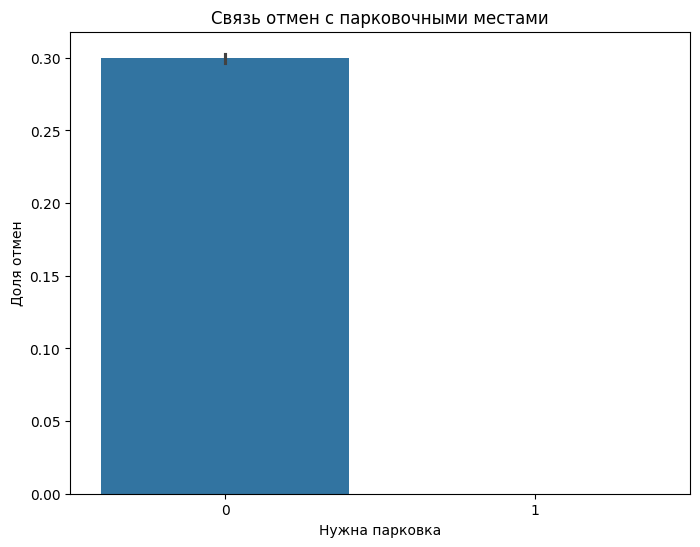

In [235]:
plt.figure(figsize=(8,6))
sns.barplot(df, x='required_car_parking_spaces', y='is_canceled')

plt.title('Связь отмен с парковочными местами')
plt.xlabel('Нужна парковка')
plt.ylabel('Доля отмен')

plt.show()

In [236]:
df = df.drop(columns= ['required_car_parking_spaces'])

### Признак total_of_special_requests
Что значит?
- сколько каких то специальных запросов сделал клиент

In [237]:
df['total_of_special_requests'].isna().sum() #net

np.int64(0)

In [238]:
df['total_of_special_requests'].value_counts()

total_of_special_requests
0    43814
1    28919
2    11774
3     2303
4      318
5       36
Name: count, dtype: int64

Опять мало значений после трех, объединяем

In [239]:
df['total_of_special_requests'] =df['total_of_special_requests'].apply(lambda x: x if x < 3 else '>2')
df['total_of_special_requests'].value_counts()

total_of_special_requests
0     43814
1     28919
2     11774
>2     2657
Name: count, dtype: int64

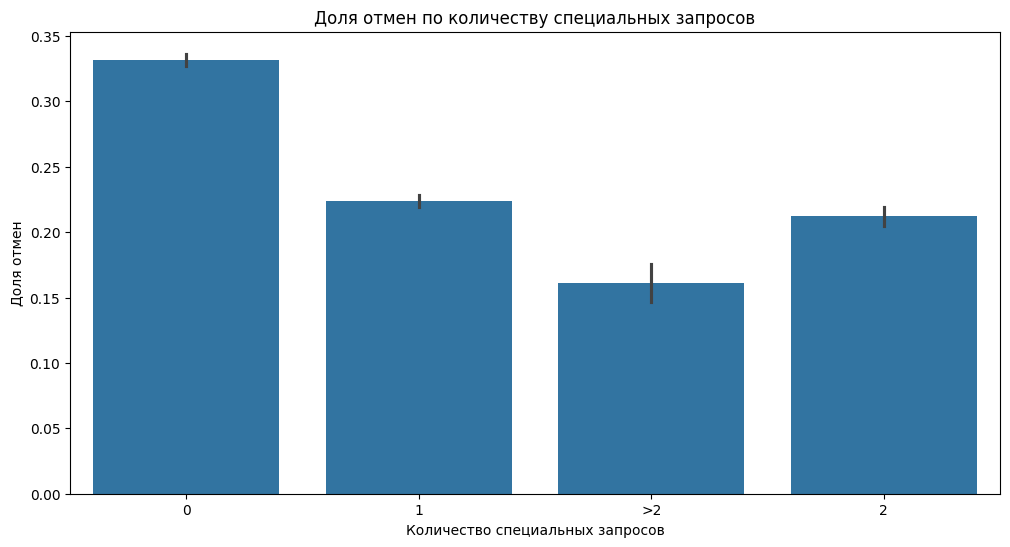

In [240]:
plt.figure(figsize=(12,6))
sns.barplot(df, x='total_of_special_requests', y='is_canceled')

plt.title('Доля отмен по количеству специальных запросов')
plt.xlabel('Количество специальных запросов')
plt.ylabel('Доля отмен')

plt.show()

Неплохой признак, по сути чем больше специальных запросов, тем меньше вероятность отмены, надо проверять

### Признак reservation_status
Что значит?
- статус бронирования

Удаляем, ничего полезного, дублирует по сути таргет

In [241]:
df['reservation_status'].unique()

<StringArray>
['Check-Out', 'Canceled', 'No-Show']
Length: 3, dtype: str

In [242]:
df = df.drop(columns=['reservation_status'])

### Признак reservation_status_date
Что значит?
- дата устанвоки статуса бронирования

Ничего полезного, напрямую связана с предыдущим признаком, удаляем

In [243]:
df = df.drop(columns=['reservation_status_date'])

### Итог по тем признакам, что мы оставим в датасете

In [244]:
df.info()

<class 'pandas.DataFrame'>
Index: 87164 entries, 0 to 119389
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87164 non-null  str    
 1   is_canceled                     87164 non-null  int64  
 2   lead_time                       87164 non-null  int64  
 3   arrival_date_year               87164 non-null  int64  
 4   arrival_date_month              87164 non-null  str    
 5   arrival_date_day_of_month       87164 non-null  int64  
 6   country                         87164 non-null  str    
 7   market_segment                  87164 non-null  str    
 8   distribution_channel            87164 non-null  str    
 9   previous_cancellations          87164 non-null  int64  
 10  previous_bookings_not_canceled  87164 non-null  int64  
 11  booking_changes                 87164 non-null  object 
 12  deposit_type                    87164 non-null 

- **hotel** - две больших группы, которые мы далее сможем сравнивать между собой (два указанных отеля)

- **is_canceled** - таргет, основной признак показывающий успех/неуспех бронирования и важен для бизнеса, так что он точно будет рассмотрен далее и будет завязан в гипотезах далее.

- **lead_time** - этот признак может оказаться полезным как определяющий заранее лида, то есть далее сможем посмотреть, связано ли более раннее бронирование с успехом или наоброт. Или, как было предложено при рассмотрении признака, выделим различные варианты когорт и сравним их.

- **arrival_date_year**, **arrival_date_month**, **arrival_date_day_of_month** - это декомпозиция даты приезда, причем ее в классическом виде в датасете нет. Скорее всего, прям полная дата как отдельный признак нам и не нужен, скорее нужно будет делить на когороты по месяцам, году, в частности смотреть на год + месяц.

- **stays_in_nights**, **has_weekend_nights** - даты выезда в датасете нет, но есть количество проведенных дней, что более применимо в нашем анализе. К этому еще бинарный флаг, который может помочь нам понять - отличаются ли бронирования с наличием выходных дней в период проживания.

- **guests_categories** - категории гостей, проживающих в отеле. Признак может быть особенно полезным для того, чтобы проанализировать разных гостей и выделить наиболее выгодных для отеля, чтобы, в том числе, грамотно развивать маркетинговые кампании, выделяя наиболее удачный таргет.

- **country** - логично далее страны также объединить по какому-то признаку, к примеру, по региону: Европа, Азия, Африка и т.д. Возможно, мы увидим какие-то различия между этими группами.

- **market_segment**, **distribution_channel** - не очень ясно по итогу глобально чем отличаются признаки, просто разве что будто бы в market_segment больше детализации внутри самых популярных групп. Скорее потом оставим какой-то один, но перед этим посмотрим на них в сравнении с другими.

- **previous_cancellations**, **previous_bookings_not_canceled** - признаки довольно интересные, но в рамках нашего анализа не факт, что сможем грамотно их использовать, к тому же, там сильный дисбаланс классов, но пока оставим.

- **booking_changes** - бронирований без изменений сильно больше остальных, но в теории может быть хорошим сигналом о том, что бронирование вероятнее не будет отменено.

- **deposit_type** - может быть довольно сильным признаком, но у нас очень большой дисбаланс, так что будет скорее дополняющим основной анализ. 

- **customer_type** - дополнительная сегментация клиентов, подобно признакам выше - может быть полезно, чтобы сделать более точные выводы о том, у каких клиентов/бронирований дела обстоят хуже или лучше.

- **adr** - один из важнейших признаков, показывает в определенном виде финансовый успех + один из немногих числовых признаков. Подробнее обязательно посмотрим далее в нашем анализе.

- **total_of_special_requests** - неплохой признак, но скорее дополнящий другие.

Выгрузим получившийся датасет

In [245]:
df.to_csv('data.csv', index=False)